In [1]:
import sys
print(sys.version)

3.11.13 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:03:15) [MSC v.1929 64 bit (AMD64)]


In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())  # True if you have GPU support


2.10.0+cu126
False


C:\Users\acer\anaconda3\envs\sindy-env\Lib\site-packages\torch\cuda\__init__.py:184: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11000). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10\cuda\CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
import torch
torch.cuda.is_available()

False

In [4]:
pip install torch==2.2.2+cu118 torchvision==0.17.2+cu118 torchaudio==2.2.2 --index-url https://download.pytorch.org/whl/cu118


Looking in indexes: https://download.pytorch.org/whl/cu118
     ---------------------------------------- 0.0/2.7 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.7 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.7 GB 3.3 MB/s eta 0:13:30
     ---------------------------------------- 0.0/2.7 GB 5.8 MB/s eta 0:07:44
     ---------------------------------------- 0.0/2.7 GB 11.5 MB/s eta 0:03:56
     ---------------------------------------- 0.0/2.7 GB 12.0 MB/s eta 0:03:45
     ---------------------------------------- 0.0/2.7 GB 11.9 MB/s eta 0:03:47
     ---------------------------------------- 0.0/2.7 GB 11.9 MB/s eta 0:03:46
     ---------------------------------------- 0.0/2.7 GB 10.5 MB/s eta 0:04:18
     ---------------------------------------- 0.0/2.7 GB 13.4 MB/s eta 0:03:21
     ---------------------------------------- 0.0/2.7 GB 14.1 MB/s eta 0:03:10
     ---------------------------------------- 0.0/2.7 GB 14.1 MB/s eta 0:03:10
     ------

  You can safely remove it manually.


In [5]:
import torch
x = torch.randn(1000, 1000)
y = torch.matmul(x, x)
print("OK")

OK


In [6]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())  # True if you have GPU suppor

2.10.0+cu126
False


In [7]:
!pip install torch matplotlib numpy


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [9]:
def f(x):
    # x: tensor of shape (N,1)
    return - (np.pi**2) * torch.sin(np.pi * x)


In [10]:
class PINN(nn.Module):
    def __init__(self, in_dim=1, out_dim=1, hidden_dim=64, num_hidden_layers=3):
        super().__init__()
        layers = []
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.Tanh())
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # x shape: (N,1)
        return self.net(x)


In [11]:
model = PINN().to(device)


In [12]:
def pde_residual(model, x):
    # x requires grad for autograd
    x = x.clone().detach().requires_grad_(True).to(device)
    u = model(x)
    # First derivative du/dx
    du_dx = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]
    # Second derivative d2u/dx2
    d2u_dx2 = torch.autograd.grad(
        du_dx, x,
        grad_outputs=torch.ones_like(du_dx),
        create_graph=True,
        retain_graph=True
    )[0]
    # PDE residual: u''(x) - f(x)
    res = d2u_dx2 - f(x)
    return res


In [13]:
mse_loss = nn.MSELoss()

def pinn_loss(model, x_f, x_b):
    # PDE loss
    res = pde_residual(model, x_f)
    pde_loss = mse_loss(res, torch.zeros_like(res))

    # Boundary loss
    u_b = model(x_b)
    u_b_target = torch.zeros_like(u_b)
    bc_loss = mse_loss(u_b, u_b_target)

    # Total loss (you can weight these if needed)
    loss = pde_loss + bc_loss
    return loss, pde_loss.detach(), bc_loss.detach()


In [14]:
# Interior collocation points
N_f = 1000
x_f = torch.rand(N_f, 1)  # uniform in (0,1)
x_f = x_f.to(device)

# Boundary points: x=0 and x=1
x_b0 = torch.zeros(1, 1)
x_b1 = torch.ones(1, 1)
x_b = torch.cat([x_b0, x_b1], dim=0).to(device)


In [15]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 5000
history_total = []
history_pde = []
history_bc = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    loss, pde_l, bc_l = pinn_loss(model, x_f, x_b)
    loss.backward()
    optimizer.step()

    history_total.append(loss.item())
    history_pde.append(pde_l.item())
    history_bc.append(bc_l.item())

    if (epoch+1) % 500 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Total: {loss.item():.4e} | PDE: {pde_l.item():.4e} | BC: {bc_l.item():.4e}")


AttributeError: module 'torch._functorch.eager_transforms' has no attribute 'grad_and_value'

In [16]:
AttributeError: module 'torch._functorch.eager_transforms' has no attribute 'grad_and_value'

SyntaxError: invalid syntax (3989229960.py, line 1)

In [17]:
pip uninstall torch torchvision torchaudio -y


Found existing installation: torch 2.2.2+cu118
Uninstalling torch-2.2.2+cu118:
  Successfully uninstalled torch-2.2.2+cu118
Found existing installation: torchvision 0.17.2+cu118
Uninstalling torchvision-0.17.2+cu118:
  Successfully uninstalled torchvision-0.17.2+cu118
Found existing installation: torchaudio 2.2.2+cu118
Uninstalling torchaudio-2.2.2+cu118:
  Successfully uninstalled torchaudio-2.2.2+cu118
Note: you may need to restart the kernel to use updated packages.


In [18]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu
   ---------------------------------------- 0.0/113.6 MB ? eta -:--:--
   ---------------------------------------- 0.5/113.6 MB 3.3 MB/s eta 0:00:35
   - -------------------------------------- 3.4/113.6 MB 8.7 MB/s eta 0:00:13
   -- ------------------------------------- 7.1/113.6 MB 13.2 MB/s eta 0:00:09
   -- ------------------------------------- 7.1/113.6 MB 13.2 MB/s eta 0:00:09
   ---- ---------------------------------- 13.6/113.6 MB 14.0 MB/s eta 0:00:08
   ----- --------------------------------- 14.9/113.6 MB 13.8 MB/s eta 0:00:08
   ------ -------------------------------- 20.2/113.6 MB 14.8 MB/s eta 0:00:07
   ------- ------------------------------- 20.4/113.6 MB 12.8 MB/s eta 0:00:08
   ---------- ---------------------------- 29.4/113.6 MB 16.3 MB/s eta 0:00:06
   ---------- ---------------------------- 30.7/113.6 MB 14.7 MB/s eta 0:00:06
   ----------- --------------------------- 33.8/113.6 MB 15.8 MB/s eta 0:00:06
   --

In [19]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())


2.10.0+cu126
False


In [20]:
2.x.x
False


SyntaxError: invalid decimal literal (1494616433.py, line 1)

In [ ]:
pip install torch==2.2.2+cu118 torchvision==0.17.2+cu118 torchaudio==2.2.2 --index-url https://download.pytorch.org/whl/cu118


In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [21]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 5000
history_total = []
history_pde = []
history_bc = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    loss, pde_l, bc_l = pinn_loss(model, x_f, x_b)
    loss.backward()
    optimizer.step()

    history_total.append(loss.item())
    history_pde.append(pde_l.item())
    history_bc.append(bc_l.item())

    if (epoch+1) % 500 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Total: {loss.item():.4e} | PDE: {pde_l.item():.4e} | BC: {bc_l.item():.4e}")

Epoch 500/5000 | Total: 2.2380e-03 | PDE: 2.2377e-03 | BC: 3.2613e-07
Epoch 1000/5000 | Total: 1.8708e-03 | PDE: 1.8708e-03 | BC: 8.3221e-08
Epoch 1500/5000 | Total: 1.4692e-03 | PDE: 1.4692e-03 | BC: 6.3809e-08
Epoch 2000/5000 | Total: 9.2485e-04 | PDE: 9.2481e-04 | BC: 3.5313e-08
Epoch 2500/5000 | Total: 3.2492e-04 | PDE: 3.2491e-04 | BC: 1.0997e-08
Epoch 3000/5000 | Total: 4.3175e-05 | PDE: 4.3174e-05 | BC: 5.6174e-10
Epoch 3500/5000 | Total: 3.0637e-05 | PDE: 3.0637e-05 | BC: 1.4760e-10
Epoch 4000/5000 | Total: 3.2714e-03 | PDE: 3.0874e-03 | BC: 1.8402e-04
Epoch 4500/5000 | Total: 3.8959e-05 | PDE: 3.8128e-05 | BC: 8.3070e-07
Epoch 5000/5000 | Total: 1.7434e-05 | PDE: 1.7434e-05 | BC: 2.7240e-10


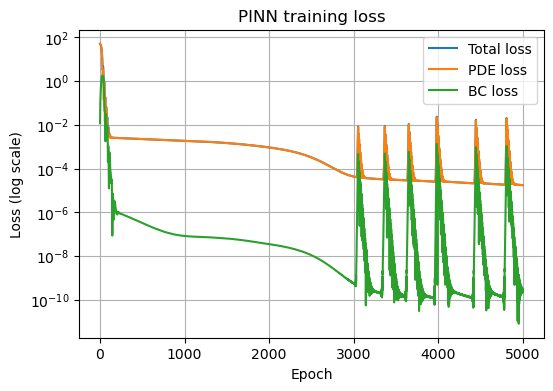

In [22]:
plt.figure(figsize=(6,4))
plt.semilogy(history_total, label='Total loss')
plt.semilogy(history_pde, label='PDE loss')
plt.semilogy(history_bc, label='BC loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.legend()
plt.title('PINN training loss')
plt.grid(True)
plt.show()


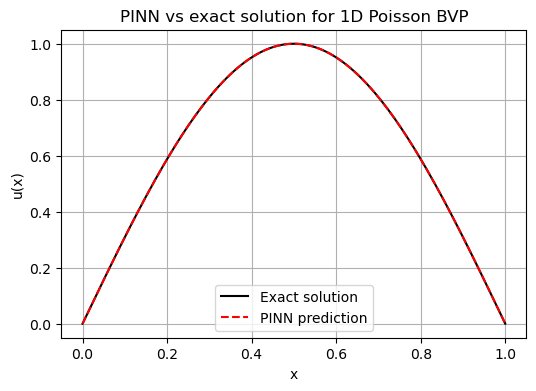

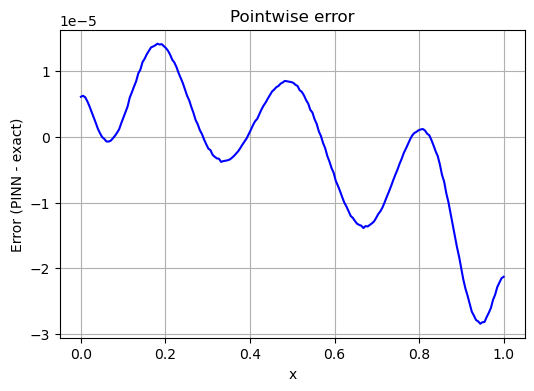

In [23]:
model.eval()
x_test = torch.linspace(0, 1, 200).view(-1,1).to(device)
with torch.no_grad():
    u_pred = model(x_test).cpu().numpy()

x_np = x_test.cpu().numpy()
u_exact = np.sin(np.pi * x_np)

# Plot
plt.figure(figsize=(6,4))
plt.plot(x_np, u_exact, 'k-', label='Exact solution')
plt.plot(x_np, u_pred, 'r--', label='PINN prediction')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.title('PINN vs exact solution for 1D Poisson BVP')
plt.grid(True)
plt.show()

# Error plot
plt.figure(figsize=(6,4))
plt.plot(x_np, u_pred - u_exact, 'b-')
plt.xlabel('x')
plt.ylabel('Error (PINN - exact)')
plt.title('Pointwise error')
plt.grid(True)
plt.show()


In [24]:
#2nd TASK
def pinn_loss(model, x_f, x_b, w_pde=1.0, w_bc=10.0):
    res = pde_residual(model, x_f)
    pde_loss = mse_loss(res, torch.zeros_like(res))
    u_b = model(x_b)
    bc_loss = mse_loss(u_b, torch.zeros_like(u_b))
    loss = w_pde * pde_loss + w_bc * bc_loss
    return loss, pde_loss.detach(), bc_loss.detach()


In [25]:
class PINN_BC(nn.Module):
    def __init__(self, in_dim=1, out_dim=1, hidden_dim=64, num_hidden_layers=3):
        super().__init__()
        layers = []
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.Tanh())
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        N = self.net(x)
        return x * (1 - x) * N  # enforces u(0)=u(1)=0


In [26]:
optimizer_lbfgs = optim.LBFGS(model.parameters(), lr=1.0, max_iter=500)

def closure():
    optimizer_lbfgs.zero_grad()
    loss, _, _ = pinn_loss(model, x_f, x_b)
    loss.backward()
    return loss

optimizer_lbfgs.step(closure)

tensor(1.7425e-05, grad_fn=<AddBackward0>)